In [2]:
import fitness_landscape as fl
import os
import pandas as pd
import numpy as np
import pickle
import json
from pathlib import Path
import networkx as nx
from tqdm import tqdm

### DMS and Megascale folding dataset

In [3]:
# Prepare file list
file_list = os.listdir('../data_files/protein_gym/DMS_assays_substitutions')
file_list = [file for file in file_list if file != '.DS_Store']
file_list.sort()

# Initialise empty results list
results = []

for _, file in tqdm(enumerate(file_list)):
    df = pd.read_csv(os.path.join('../data_files/protein_gym/DMS_assays_substitutions/', file))

    # Skip large datasets
    if len(df) > 4000:
        continue

    # Extract sequence objects
    sequences = [fl.BaseNumpySequence(sequence) for sequence in df['mutated_sequence']]
    fitness = np.array(df['DMS_score'])

    rep_out = {
        "file": str(file),
        "n_sequences": len(sequences)}

    # Construct fitness landscape with Hamming graph for DMS data
    landscape = fl.FitnessLandscape.build(
        sequences,
        graph="hamming",
    )

    # Check if there is more than a single connected component and skip if so
    G = landscape.graph  # nx.Graph
    if not nx.is_connected(G):
        continue

    # Attach fitness values
    layer_name = f"dms_score"
    landscape.attach(name=layer_name, values=fitness, dtype="numeric")
    landscape.view(layer_name)

    # Compute tmap results
    tmap_res = fl.analysis.diffusion_scale.compute_ruggedness_diffusion_scale(landscape, t_min=1e-10, t_max=1e2)

    # Collect results
    rep_out["tmap"] =  tmap_res
    results.append(rep_out)

210it [45:08, 12.90s/it]


ParserError: Error tokenizing data. C error: Expected 1 fields in line 3, saw 2


In [4]:
results

[{'file': 'A0A1I9GEU1_NEIME_Kennouche_2019.csv',
  'n_sequences': 922,
  'tmap': {'t_map': 5.4126291836759104e-06,
   't_lower_confidence_interval': 1e-10,
   't_upper_confidence_interval': 100.0,
   't_logposterior_map': np.float64(-1706.199652497443),
   'variance_approximate': 1000000000000.0}},
 {'file': 'A0A247D711_LISMN_Stadelmann_2021.csv',
  'n_sequences': 1653,
  'tmap': {'t_map': 6.510813047253762e-06,
   't_lower_confidence_interval': 1e-10,
   't_upper_confidence_interval': 3.784689714741965,
   't_logposterior_map': np.float64(-2780.2325264259025),
   'variance_approximate': np.float64(3.7286096819298358)}},
 {'file': 'A0A2Z5U3Z0_9INFA_Wu_2014.csv',
  'n_sequences': 2350,
  'tmap': {'t_map': 4.135254900909049e-06,
   't_lower_confidence_interval': 1e-10,
   't_upper_confidence_interval': 12.018849986337331,
   't_logposterior_map': np.float64(-3305.837588584259),
   'variance_approximate': np.float64(37.602211472324385)}},
 {'file': 'AACC1_PSEAI_Dandage_2018.csv',
  'n_seq

In [5]:
out_pkl = Path("../data_files/protein_gym/DMS_assays_substitutions/megascale_folding_tmap.pkl")
out_json = Path("../data_files/protein_gym/DMS_assays_substitutions/megascale_folding_tmap.json")

def _jsonable(obj):
    import numpy as np

    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    if isinstance(obj, dict):
        return {str(k): _jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_jsonable(x) for x in obj]
    return obj

# Save pickle
with open(out_pkl, "wb") as f:
    pickle.dump(results, f)

# Save json
with open(out_json, "w") as f:
    json.dump(_jsonable(results), f, indent=2)


In [2]:
# Reload results
out_pkl = Path("../data_files/protein_gym/DMS_assays_substitutions/megascale_folding_tmap.pkl")

with open(out_pkl, "rb") as f:
    results = pickle.load(f)

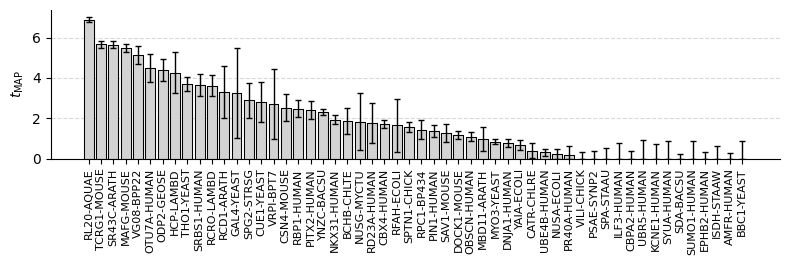

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

rows = []
for r in results:
    fname = r["file"].replace(".csv", "")
    dataset = "-".join(fname.split("_")[0:2])

    rows.append({
        "dataset": dataset,
        "t": float(r["tmap"]["t_map"]),
        "t_lo": float(r["tmap"]["t_lower_confidence_interval"]),
        "t_hi": float(r["tmap"]["t_upper_confidence_interval"]),
    })

df = pd.DataFrame(rows)

# sort by t descending
df = df.sort_values("t", ascending=False).reset_index(drop=True)

# Drop poorly fitted datasets
for c in ["t", "t_lo", "t_hi"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Define poor-fit mask
poor_fit = ((df["t_hi"] / df["t_lo"]) >= 10.0) & (df["t_hi"] > 1.0)

# Drop them
df = df.loc[~poor_fit].reset_index(drop=True)

# sort by t descending
df = df.sort_values("t", ascending=False).reset_index(drop=True)

# asymmetric error bars
yerr = np.vstack([
    df["t"] - df["t_lo"],
    df["t_hi"] - df["t"]
])

fig, ax = plt.subplots(figsize=(8, 2.75))

ax.bar(
    df["dataset"],
    df["t"],
    color="lightgrey",
    edgecolor="black",
    linewidth=0.75,
    zorder=2
)

ax.errorbar(
    x=np.arange(len(df)),
    y=df["t"],
    yerr=yerr,
    fmt="none",
    ecolor="black",
    elinewidth=1,
    capsize=2,
    zorder=3
)

ax.set_xticks(np.arange(len(df)))
ax.set_xticklabels(df["dataset"], rotation=90, fontsize=8)

ax.set_ylabel(r"$t_{\mathrm{MAP}}$")
# ax.set_yscale("log") 

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", ls="--", c="0.85", zorder=1)

x = np.arange(len(df))

ax.bar(
    x,
    df["t"],
    color="lightgrey",
    edgecolor="black",
    linewidth=0.75,
    zorder=2
)

# show only every 3rd label
step = 1
ax.set_xticks(x[::step])
ax.set_xticklabels(df["dataset"].iloc[::step], rotation=90, )

plt.tight_layout()
plt.savefig("../figures/figure_2/tmap_vs_dms.pdf")
plt.show()

## Sparse datasets

In [ ]:
# Prepare file list
file_list = os.listdir('../data_files/sparse_datasets')
file_list = [file for file in file_list if file != '.DS_Store']
file_list.sort()

# Initialise empty results list
results = []

for _, file in tqdm(enumerate(file_list)):
    df = pd.read_csv(os.path.join('../data_files/sparse_datasets/', file))

    if len(df) > 4000:
        continue

    # Extract sequence objects
    seqs_raw = df["sequence"].astype(str).str.strip().str.replace(".", "-", regex=False)

    L = seqs_raw.str.len().max()  # target alignment length
    seqs_raw = seqs_raw.str.pad(width=L, side="right", fillchar="-")

    sequences = [fl.BaseNumpySequence(s) for s in seqs_raw]
    fitness = df["fitness"].to_numpy()

    # Scale K to sqrt of number of sequences
    knn_k = max(int(np.sqrt(len(sequences))), 2)

    rep_out = {
        "file": str(file),
        "n_sequences": len(sequences),
        "knn_k": knn_k}

    # Construct fitness landscape
    landscape = fl.FitnessLandscape.build(
        sequences,
        graph="knn",
        k=knn_k,
        backend="auto",
        _compute_hamming_edges=False
    )

    
    # Attach fitness values
    layer_name = f"fitness"
    landscape.attach(name=layer_name, values=fitness, dtype="numeric")
    landscape.view(layer_name)

    # Check if there is more than a single connected component and proceed on the largest connected component if so
    G = landscape.graph  # nx.Graph
    if not nx.is_connected(G):

        landscape = landscape.get_components()[0]
        continue

    # Compute tmap results
    tmap_res = fl.analysis.diffusion_scale.compute_ruggedness_diffusion_scale(landscape, t_min=1e-10, t_max=1e2)

    # Collect results
    rep_out["tmap"] =  tmap_res
    results.append(rep_out)

1it [00:00,  2.38it/s]/home/matthewspence/graph-ruggedness-de/.env/lib/python3.13/site-packages/fitness_landscape/core/landscape.py:728: UserWarning: Duplicate sequences detected for 40 keys; downstream `attach()` policies will handle them.
  warnings.warn(f"Duplicate sequences detected for {len(dupes)} keys; "
2it [00:01,  1.39it/s]/home/matthewspence/graph-ruggedness-de/.env/lib/python3.13/site-packages/fitness_landscape/core/landscape.py:728: UserWarning: Duplicate sequences detected for 1 keys; downstream `attach()` policies will handle them.
  warnings.warn(f"Duplicate sequences detected for {len(dupes)} keys; "
5it [00:03,  1.51it/s]/home/matthewspence/graph-ruggedness-de/.env/lib/python3.13/site-packages/fitness_landscape/core/landscape.py:728: UserWarning: Duplicate sequences detected for 13 keys; downstream `attach()` policies will handle them.
  warnings.warn(f"Duplicate sequences detected for {len(dupes)} keys; "
7it [00:03,  2.32it/s]/home/matthewspence/graph-ruggedness-de/

In [77]:
out_pkl = Path("../data_files/sparse_datasets/sparse_data_tmap.pkl")
out_json = Path("../data_files/sparse_datasets/sparse_data_tmap.json")

def _jsonable(obj):
    import numpy as np

    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    if isinstance(obj, dict):
        return {str(k): _jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_jsonable(x) for x in obj]
    return obj

# Save pickle
with open(out_pkl, "wb") as f:
    pickle.dump(results, f)

# Save json
with open(out_json, "w") as f:
    json.dump(_jsonable(results), f, indent=2)

In [81]:
file_list

['CM_natural.csv',
 'LacI_DBD.csv',
 'PETase.csv',
 'PPAT.csv',
 '_CM_designed.csv',
 'cusod.csv',
 'lysozyme_designed.csv',
 'mph.csv']

In [82]:
file

'mph.csv'